# Risk Analysis - Logistic Regression

# Load Data & Library

In [1]:
# --- SECTION 1: LOAD DATA & LIBRARY ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Library Machine Learning (Ditambah LogisticRegression untuk komparasi)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

# 1. DETEKSI PATH OTOMATIS
current_dir = os.getcwd()
path_file = os.path.join(current_dir, "..", "Data", "Processed", "ecommerce_clean.csv")

try:
    df = pd.read_csv(path_file)
    
    # --- PROSES PEMBERSIHAN NAMA KOLOM ---
    df.columns = [col.strip().capitalize() for col in df.columns]
    
    print("Berhasil! Data berhasil dimuat dengan path otomatis.")
    print(f"Kolom yang tersedia: {df.columns.tolist()}")
    display(df.head())
except Exception as e:
    print(f"Gagal memuat data! Periksa apakah file ada di: {path_file}")
    print(f"Error: {e}")

Berhasil! Data berhasil dimuat dengan path otomatis.
Kolom yang tersedia: ['Order_id', 'Order_date', 'Customer_name', 'Region', 'City', 'Category', 'Sub_category', 'Product_name', 'Quantity', 'Unit_price', 'Discount', 'Sales', 'Profit', 'Payment_mode', 'Month', 'Year', 'Is_trending']


,Order_id,Order_date,Customer_name,Region,City,Category,Sub_category,Product_name,Quantity,Unit_price,Discount,Sales,Profit,Payment_mode,Month,Year,Is_trending
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,0
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,0
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,1
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,5,2025,1
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,1,2025,0


# Labeling

In [2]:
# --- SECTION 2: LABELING ---

# Menghitung margin (Profit dibagi Penjualan)
# Kita gunakan kolom yang sudah dirapikan namanya (Capitalized)
df['Margin'] = df['Profit'] / df['Sales']

# Kita tentukan 15% transaksi dengan margin terendah sebagai 'Risiko'
threshold = df['Margin'].quantile(0.15)

# Membuat kolom target 'Is_risk'
# 1 artinya Berisiko, 0 artinya Aman
df['Is_risk'] = (df['Margin'] <= threshold).astype(int)

print(f"Threshold margin untuk risiko: {threshold:.2%}")
print("\nDistribusi Data (0: Aman, 1: Risiko):")
print(df['Is_risk'].value_counts())

# Menampilkan statistik singkat untuk memastikan labeling logis
display(df.groupby('Is_risk')[['Profit', 'Margin']].mean())

Threshold margin untuk risiko: 8.02%

Distribusi Data (0: Aman, 1: Risiko):
Is_risk
0    4250
1     750
Name: count, dtype: int64


,Profit,Margin
Is_risk,,
0,17543.395988,0.164081
1,6865.735947,0.065133


# Data Preparation

In [5]:
# --- SECTION 3: DATA PREPARATION ---

# 1. Pilih Fitur Utama (X) dan Target (y)
# List fitur yang kita inginkan
features = ['Region', 'Category', 'Discount', 'Quantity', 'Unit price']

# Logika Pengaman: Hanya mengambil kolom yang benar-benar ada di dataframe
X = df[[col for col in features if col in df.columns]]

# Logika Pengaman untuk Target: Mengecek variasi penulisan Is_risk
if 'Is_risk' in df.columns:
    y = df['Is_risk']
elif 'Is_Risk' in df.columns:
    y = df['Is_Risk']
else:
    # Jika tidak ada, ambil kolom terakhir (asumsi hasil labeling)
    y = df.iloc[:, -1] 

# 2. Encoding: Mengubah kolom kategori menjadi angka
# Kita tentukan secara spesifik kolom mana yang perlu di-encode
kolom_kategori = [col for col in ['Region', 'Category'] if col in X.columns]
X_encoded = pd.get_dummies(X, columns=kolom_kategori, drop_first=True)

# 3. Split Data: 80% Latih, 20% Uji
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Persiapan selesai!")
print(f"Fitur yang berhasil dimuat: {X.columns.tolist()}")
print(f"Target yang digunakan: {y.name}")

Persiapan selesai!
Fitur yang berhasil dimuat: ['Region', 'Category', 'Discount', 'Quantity']
Target yang digunakan: Is_risk


# Model Training

In [8]:
# --- REVISI SECTION 4: MODEL TRAINING ---

# Menambahkan class_weight='balanced' agar model peduli pada data risiko
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Pelatihan ulang
print("Melatih ulang Logistic Regression dengan bobot seimbang...")
lr_model.fit(X_train, y_train)

# Random Forest biasanya lebih tahan, tapi kita tetap latih ulang
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Selesai!")
print("Kedua model siap untuk dibandingkan di tahap evaluasi.")

Melatih ulang Logistic Regression dengan bobot seimbang...
Selesai!
Kedua model siap untuk dibandingkan di tahap evaluasi.


# Evaluation

--- PERBANDINGAN AKURASI ---
Akurasi Logistic Regression : 44.10%
Akurasi Random Forest       : 82.10%
------------------------------

[ Laporan Klasifikasi Detail: Logistic Regression ]
              precision    recall  f1-score   support

           0       0.85      0.42      0.56       850
           1       0.15      0.58      0.24       150

    accuracy                           0.44      1000
   macro avg       0.50      0.50      0.40      1000
weighted avg       0.74      0.44      0.51      1000



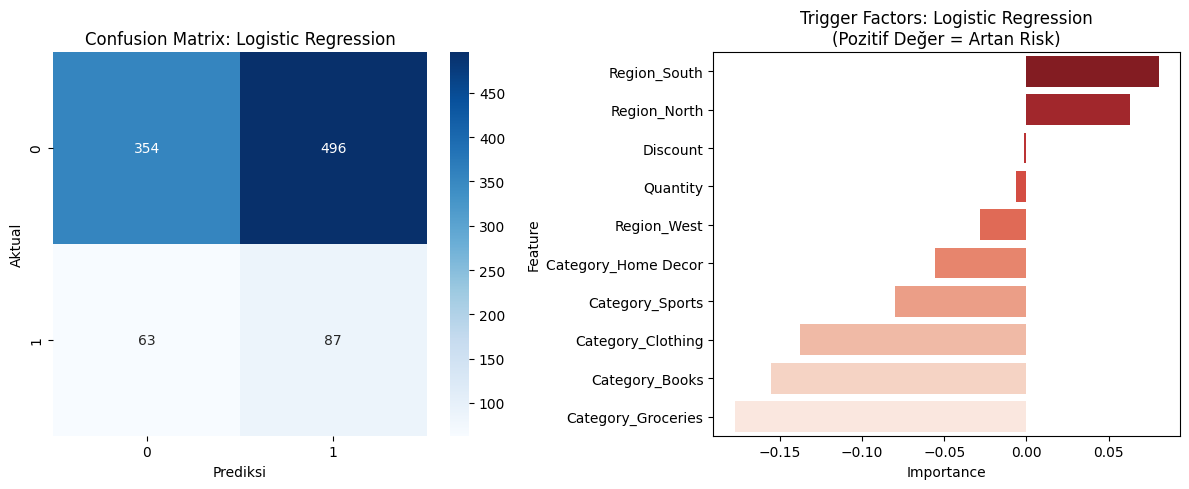

In [16]:
# --- REVISI SECTION 5: EVALUATION & LOGISTIC TRIGGER FACTORS ---

# 1. Prediksi menggunakan kedua model pada data uji
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 2. Hitung Akurasi untuk Komparasi
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("--- PERBANDINGAN AKURASI ---")
print(f"Akurasi Logistic Regression : {acc_lr:.2%}")
print(f"Akurasi Random Forest       : {acc_rf:.2%}")
print("-" * 30)

# 3. Laporan Klasifikasi Detail (Fokus pada Logistic Regression)
print("\n[ Laporan Klasifikasi Detail: Logistic Regression ]")
print(classification_report(y_test, y_pred_lr))

# 4. Visualisasi (Confusion Matrix & LR Trigger Factors)
plt.figure(figsize=(12, 5))

# Subplot 1: Confusion Matrix Logistic Regression
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Subplot 2: Trigger Factors Logistic Regression (Pemicu Risiko)
# Mengambil koefisien untuk melihat arah pengaruh fitur
lr_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': lr_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=lr_importance.head(10), 
            hue='Feature', palette='Reds_r', legend=False)
plt.title('Trigger Factors: Logistic Regression\n(Pozitif Değer = Artan Risk)')

plt.tight_layout()
plt.show()

# Save Model

In [15]:
# --- REVISI SECTION 6: SAVE MODEL (LANGSUNG DI FOLDER NOTEBOOKS) ---

# 1. Simpan Model Logistic Regression
joblib.dump(lr_model, 'model_risiko_logistic.pkl')

# 2. Simpan Model Random Forest (Pembanding)
joblib.dump(rf_model, 'model_risiko_rf_compare.pkl')

# 3. Simpan Daftar Fitur
joblib.dump(X_train.columns.tolist(), 'risk_features_logistic.pkl')

print("✅ Berhasil! Semua file .pkl disimpan langsung di folder Notebooks.")

✅ Berhasil! Semua file .pkl disimpan langsung di folder Notebooks.
